In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('Online Retail.xlsx')

In [5]:
df = df.dropna(subset=["CustomerID"])

In [6]:
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [7]:
df = df[df["Quantity"] > 0]

In [8]:
df = df[df["UnitPrice"] > 0]

Revenue Column

In [9]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [10]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

Reference Date

In [31]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

Counting RFM

In [12]:
#Recency
recency = df.groupby("CustomerID")["InvoiceDate"].max()
recency = (reference_date - recency).dt.days

#Frequency
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()

#Monetry
monetary = df.groupby("CustomerID")["Revenue"].sum()

Combine RFM

In [13]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

RFM Scoring

In [15]:
#Recency Score
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5, 4, 3, 2, 1])

#Frequency
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5])

#Monetary Score
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

RFM Score

In [17]:
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,7,4310.00,5,5,5,555
12348.0,75,4,1797.24,2,4,4,244
12349.0,19,1,1757.55,4,1,4,414
12350.0,310,1,334.40,1,1,2,112


Customer Segmentation

In [22]:
from ast import Return
def segment_customer(row):

  if row["RFM_score"] == "555":
    return "Champions"

  if row["R_score"] >= 4 and row["F_score"] >= 4:
    return "Loyal Customers"

  if row["R_score"] >= 4 and row["F_score"] <= 2:
    return "New Customers"

  if row["R_score"] <= 2 and row["F_score"] >= 4:
    return "At Risk"

  return "Others"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

Segment Distrubution

In [23]:
rfm["Segment"].value_counts()

,count
Segment,
Others,2605
Loyal Customers,791
Champions,348
New Customers,319
At Risk,275


Visualization

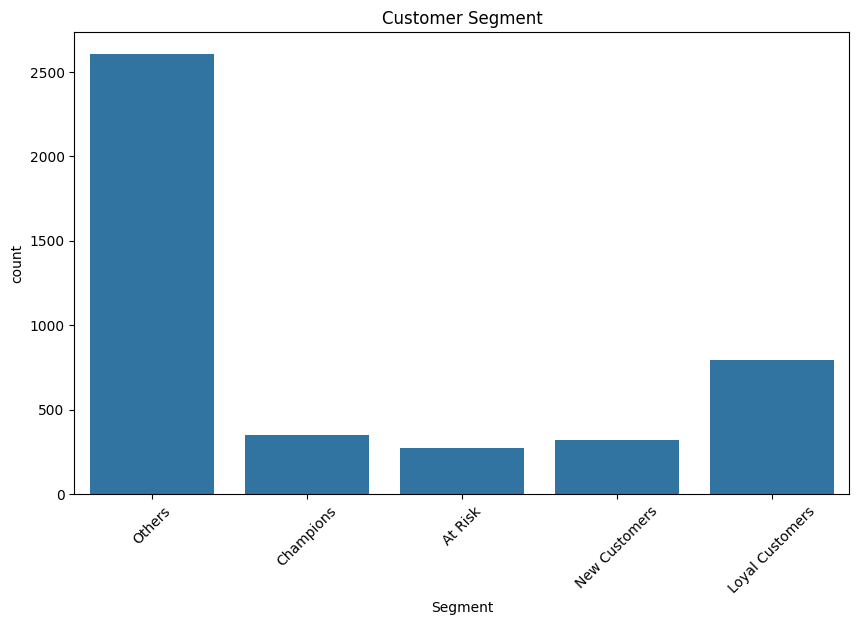

<Figure size 640x480 with 0 Axes>

In [32]:
#Segment DIstribution

plt.figure(figsize=(10, 6))

sns.countplot(data=rfm, x="Segment")

plt.title("Customer Segment")

plt.xticks(rotation=45)

plt.show()
plt.savefig("customer_segment.png")

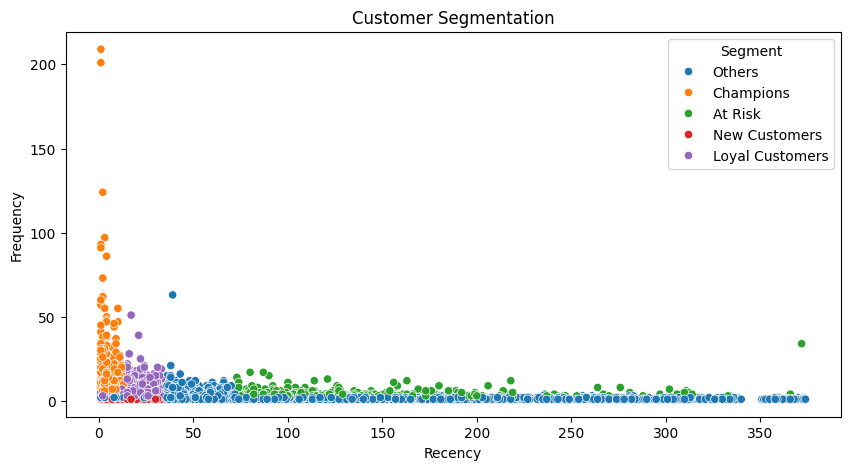

<Figure size 640x480 with 0 Axes>

In [33]:
#RFM

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Frequency",
    hue="Segment",
)

plt.title("Customer Segmentation")

plt.show()
plt.savefig("RFM.png")

In [34]:
rfm.to_csv("customer_rfm_segmentation")